In [1]:
# AI4I 2020 데이터 읽기 -> 확인 -> EDA -> 전처리 -> 저장 -> ML

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [4]:
pd.set_option("display.max_columns", None)
# pd.set_option("display.float_format", "{:.3f}".format)
plt.rcParams["figure.figsize"] = (8, 4)

In [5]:
# 1. 파일 경로 설정
file_path = "data/raw/ai4i2020.csv"

In [6]:
# 2. 데이터 읽기
df = pd.read_csv(file_path)
print("데이터 크기")
print(df.shape)

데이터 크기
(10000, 14)


In [7]:
df

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.100,308.600,1551,42.800,0,0,0,0,0,0,0
1,2,L47181,L,298.200,308.700,1408,46.300,3,0,0,0,0,0,0
2,3,L47182,L,298.100,308.500,1498,49.400,5,0,0,0,0,0,0
3,4,L47183,L,298.200,308.600,1433,39.500,7,0,0,0,0,0,0
4,5,L47184,L,298.200,308.700,1408,40.000,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.800,308.400,1604,29.500,14,0,0,0,0,0,0
9996,9997,H39410,H,298.900,308.400,1632,31.800,17,0,0,0,0,0,0
9997,9998,M24857,M,299.000,308.600,1645,33.400,22,0,0,0,0,0,0
9998,9999,H39412,H,299.000,308.700,1408,48.500,25,0,0,0,0,0,0


In [8]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [9]:
df.columns = [
    "udi", "product_id", "type",
    "air_temp_k", "process_temp_k", "rotational_speed_rpm",
    "torque_nm", "tool_wear_min",
    "machine_failure", "twf", "hdf", "pwf", "osf", "rnf"
]
print("정리된 컬럼명")
print(df.columns.tolist())

정리된 컬럼명
['udi', 'product_id', 'type', 'air_temp_k', 'process_temp_k', 'rotational_speed_rpm', 'torque_nm', 'tool_wear_min', 'machine_failure', 'twf', 'hdf', 'pwf', 'osf', 'rnf']


In [10]:
# 4. 기본 정보 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   udi                   10000 non-null  int64  
 1   product_id            10000 non-null  object 
 2   type                  10000 non-null  object 
 3   air_temp_k            10000 non-null  float64
 4   process_temp_k        10000 non-null  float64
 5   rotational_speed_rpm  10000 non-null  int64  
 6   torque_nm             10000 non-null  float64
 7   tool_wear_min         10000 non-null  int64  
 8   machine_failure       10000 non-null  int64  
 9   twf                   10000 non-null  int64  
 10  hdf                   10000 non-null  int64  
 11  pwf                   10000 non-null  int64  
 12  osf                   10000 non-null  int64  
 13  rnf                   10000 non-null  int64  
dtypes: float64(3), int64(9), object(2)
memory usage: 1.1+ MB


In [11]:
print("기초 통계량")
display(df.describe())

기초 통계량


,udi,air_temp_k,process_temp_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,twf,hdf,pwf,osf,rnf
count,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000
mean,5000.500,300.005,310.006,1538.776,39.987,107.951,0.034,0.005,0.011,0.009,0.010,0.002
std,2886.896,2.000,1.484,179.284,9.969,63.654,0.181,0.068,0.107,0.097,0.099,0.044
min,1.000,295.300,305.700,1168.000,3.800,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,2500.750,298.300,308.800,1423.000,33.200,53.000,0.000,0.000,0.000,0.000,0.000,0.000
50%,5000.500,300.100,310.100,1503.000,40.100,108.000,0.000,0.000,0.000,0.000,0.000,0.000
75%,7500.250,301.500,311.100,1612.000,46.800,162.000,0.000,0.000,0.000,0.000,0.000,0.000
max,10000.000,304.500,313.800,2886.000,76.600,253.000,1.000,1.000,1.000,1.000,1.000,1.000


In [12]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
udi,10000.000,5000.500,2886.896,1.000,2500.750,5000.500,7500.250,10000.000
air_temp_k,10000.000,300.005,2.000,295.300,298.300,300.100,301.500,304.500
process_temp_k,10000.000,310.006,1.484,305.700,308.800,310.100,311.100,313.800
rotational_speed_rpm,10000.000,1538.776,179.284,1168.000,1423.000,1503.000,1612.000,2886.000
torque_nm,10000.000,39.987,9.969,3.800,33.200,40.100,46.800,76.600
tool_wear_min,10000.000,107.951,63.654,0.000,53.000,108.000,162.000,253.000
machine_failure,10000.000,0.034,0.181,0.000,0.000,0.000,0.000,1.000
twf,10000.000,0.005,0.068,0.000,0.000,0.000,0.000,1.000
hdf,10000.000,0.011,0.107,0.000,0.000,0.000,0.000,1.000
pwf,10000.000,0.009,0.097,0.000,0.000,0.000,0.000,1.000


In [13]:
# 5. 결측치 / 중복 확인
print("컬럼별 결측치 개수")
display(df.isnull().sum())

컬럼별 결측치 개수


udi                     0
product_id              0
type                    0
air_temp_k              0
process_temp_k          0
rotational_speed_rpm    0
torque_nm               0
tool_wear_min           0
machine_failure         0
twf                     0
hdf                     0
pwf                     0
osf                     0
rnf                     0
dtype: int64

In [14]:
print("전체 결측치 개수:", df.isnull().sum().sum())

전체 결측치 개수: 0


In [15]:
print("중복 행 개수:", df.duplicated().sum())

중복 행 개수: 0


In [16]:
# 6. 범주형 분포 확인
print("type 분포")
display(df["type"].value_counts())

type 분포


type
L    6000
M    2997
H    1003
Name: count, dtype: int64

In [17]:
print("--- machine_failure 분포 ---")
display(df["machine_failure"].value_counts())

--- machine_failure 분포 ---


machine_failure
0    9661
1     339
Name: count, dtype: int64

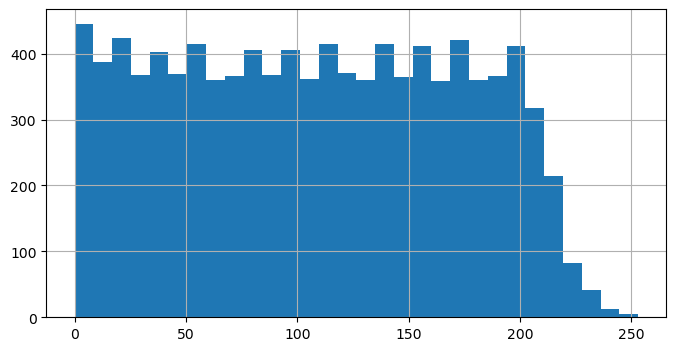

In [18]:
# 7. 수치형 분포 시각화
df["tool_wear_min"].hist(bins=30)
plt.show()

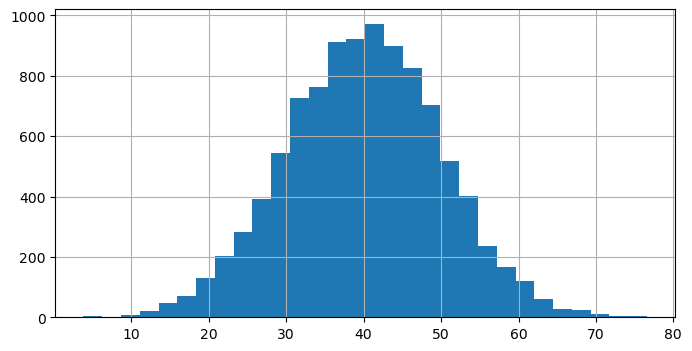

In [19]:
df["torque_nm"].hist(bins=30)
plt.show()

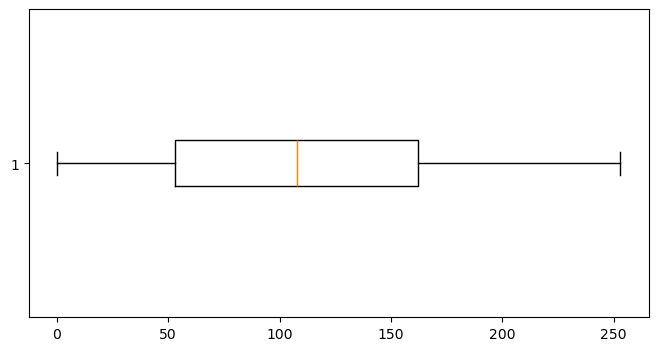

In [20]:
# 8. 박스플롯으로 이상치 확인
plt.boxplot(df["tool_wear_min"], vert=False)
plt.show()

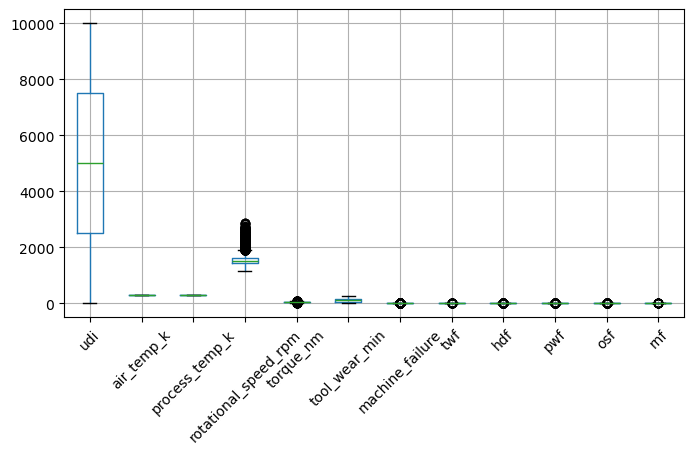

In [21]:
df.boxplot(rot=45);

In [22]:
# 9. 그룹별 요약
df.groupby("type")[["air_temp_k", "process_temp_k", "rotational_speed_rpm", "torque_nm", "tool_wear_min"]].mean().round(2)

,air_temp_k,process_temp_k,rotational_speed_rpm,torque_nm,tool_wear_min
type,,,,,
H,299.870,309.930,1538.150,39.840,107.420
L,300.020,310.010,1539.470,40.000,108.380
M,300.030,310.020,1537.600,40.020,107.270


In [23]:
print("machine_failure별 평균")
display(
    df.groupby("machine_failure")[["air_temp_k", "process_temp_k", "rotational_speed_rpm", "torque_nm", "tool_wear_min"]]
    .mean()
    .round(2)
)

machine_failure별 평균


,air_temp_k,process_temp_k,rotational_speed_rpm,torque_nm,tool_wear_min
machine_failure,,,,,
0,299.970,310.000,1540.260,39.630,106.690
1,300.890,310.290,1496.490,50.170,143.780


In [24]:
# 10. 파생 변수 만들기
# 온도_차이 = 공정_온도 - 외기_온도
df["temp_diff_k"] = df["process_temp_k"] - df["air_temp_k"]
df.head(2)

,udi,product_id,type,air_temp_k,process_temp_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,twf,hdf,pwf,osf,rnf,temp_diff_k
0,1,M14860,M,298.100,308.600,1551,42.800,0,0,0,0,0,0,0,10.500
1,2,L47181,L,298.200,308.700,1408,46.300,3,0,0,0,0,0,0,10.500


In [25]:
# 파워 = 회전수 * 토크 : 간단한 비교용 지표
df["power_index"] = df["rotational_speed_rpm"] * df["torque_nm"]
df.head(2)

,udi,product_id,type,air_temp_k,process_temp_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,twf,hdf,pwf,osf,rnf,temp_diff_k,power_index
0,1,M14860,M,298.100,308.600,1551,42.800,0,0,0,0,0,0,0,10.500,66382.800
1,2,L47181,L,298.200,308.700,1408,46.300,3,0,0,0,0,0,0,10.500,65190.400


In [26]:
# 공구 마모 구간화
df["tool_wear_level"] = pd.cut(
    df["tool_wear_min"],
    bins=[-1, 80, 160, 260],
    labels=["low", "mid", "high"]
)
df.head(2)

,udi,product_id,type,air_temp_k,process_temp_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,twf,hdf,pwf,osf,rnf,temp_diff_k,power_index,tool_wear_level
0,1,M14860,M,298.100,308.600,1551,42.800,0,0,0,0,0,0,0,10.500,66382.800,low
1,2,L47181,L,298.200,308.700,1408,46.300,3,0,0,0,0,0,0,10.500,65190.400,low


In [27]:
print("파생 변수 확인")
display(
    df[["process_temp_k", "air_temp_k", "temp_diff_k",
        "rotational_speed_rpm", "torque_nm", "power_index",
        "tool_wear_min", "tool_wear_level"]].head()
)

파생 변수 확인


,process_temp_k,air_temp_k,temp_diff_k,rotational_speed_rpm,torque_nm,power_index,tool_wear_min,tool_wear_level
0,308.600,298.100,10.500,1551,42.800,66382.800,0,low
1,308.700,298.200,10.500,1408,46.300,65190.400,3,low
2,308.500,298.100,10.400,1498,49.400,74001.200,5,low
3,308.600,298.200,10.400,1433,39.500,56603.500,7,low
4,308.700,298.200,10.500,1408,40.000,56320.000,9,low


In [28]:
# 11. 이상치 플래그 만들기
q1 = df["tool_wear_min"].quantile(0.25)
q3 = df["tool_wear_min"].quantile(0.75)
iqr = q3 - q1
print(f"q3:{q3} - q1:{q1} = iqr:{iqr}")

lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

print(f"lower_fence:{lower_fence}, upper_fence:{upper_fence}")

df["tool_wear_outlier_flag"] = (
    (df["tool_wear_min"] < lower_fence) | (df["tool_wear_min"] > upper_fence)
).astype(int)

print("공구 마모 이상치 개수:", df["tool_wear_outlier_flag"].sum())

q3:162.0 - q1:53.0 = iqr:109.0
lower_fence:-110.5, upper_fence:325.5
공구 마모 이상치 개수: 0


In [29]:
# 실제 아랫수염: lower_fence 이상인 값 중 최솟값
lower_whisker = df.loc[df["tool_wear_min"] >= lower_fence, "tool_wear_min"].min()

# 실제 윗수염: upper_fence 이하인 값 중 최댓값
upper_whisker = df.loc[df["tool_wear_min"] <= upper_fence, "tool_wear_min"].max()

print("이상치 하한 기준선:", lower_fence)
print("이상치 상한 기준선:", upper_fence)
print("실제 아랫수염:", lower_whisker)
print("실제 윗수염:", upper_whisker)

이상치 하한 기준선: -110.5
이상치 상한 기준선: 325.5
실제 아랫수염: 0
실제 윗수염: 253


In [30]:
# 12. 조건 필터링 예시
print("고장 발생 + 공구 마모 150 이상 데이터")
df[(df["machine_failure"] == 1) & (df["tool_wear_min"] >= 150)]

고장 발생 + 공구 마모 150 이상 데이터


,udi,product_id,type,air_temp_k,process_temp_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,twf,hdf,pwf,osf,rnf,temp_diff_k,power_index,tool_wear_level,tool_wear_outlier_flag
69,70,L47249,L,298.900,309.000,1410,65.700,191,1,0,0,1,1,0,10.100,92637.000,high,0
77,78,L47257,L,298.800,308.900,1455,41.300,208,1,1,0,0,0,0,10.100,60091.500,high,0
160,161,L47340,L,298.400,308.200,1282,60.700,216,1,0,0,0,1,0,9.800,77817.400,high,0
161,162,L47341,L,298.300,308.100,1412,52.300,218,1,0,0,0,1,0,9.800,73847.600,high,0
242,243,L47422,L,298.000,308.200,1348,58.800,202,1,0,0,0,1,0,10.200,79262.400,high,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9667,9668,L56847,L,299.200,310.300,1352,48.900,238,1,0,0,0,1,0,11.100,66112.800,high,0
9758,9759,L56938,L,298.600,309.800,2271,16.200,218,1,1,0,0,0,0,11.200,36790.200,high,0
9822,9823,L57002,L,298.500,309.400,1360,60.900,187,1,0,0,0,1,0,10.900,82824.000,high,0
9830,9831,L57010,L,298.300,309.300,1337,56.100,206,1,0,0,0,1,0,11.000,75005.700,high,0


In [31]:
df[(df["machine_failure"] == 1) & (df["tool_wear_level"] == "high")]

,udi,product_id,type,air_temp_k,process_temp_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,twf,hdf,pwf,osf,rnf,temp_diff_k,power_index,tool_wear_level,tool_wear_outlier_flag
69,70,L47249,L,298.900,309.000,1410,65.700,191,1,0,0,1,1,0,10.100,92637.000,high,0
77,78,L47257,L,298.800,308.900,1455,41.300,208,1,1,0,0,0,0,10.100,60091.500,high,0
160,161,L47340,L,298.400,308.200,1282,60.700,216,1,0,0,0,1,0,9.800,77817.400,high,0
161,162,L47341,L,298.300,308.100,1412,52.300,218,1,0,0,0,1,0,9.800,73847.600,high,0
242,243,L47422,L,298.000,308.200,1348,58.800,202,1,0,0,0,1,0,10.200,79262.400,high,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9667,9668,L56847,L,299.200,310.300,1352,48.900,238,1,0,0,0,1,0,11.100,66112.800,high,0
9758,9759,L56938,L,298.600,309.800,2271,16.200,218,1,1,0,0,0,0,11.200,36790.200,high,0
9822,9823,L57002,L,298.500,309.400,1360,60.900,187,1,0,0,0,1,0,10.900,82824.000,high,0
9830,9831,L57010,L,298.300,309.300,1337,56.100,206,1,0,0,0,1,0,11.000,75005.700,high,0


In [32]:
# 13. 최종 확인
print("데이터 크기:", df.shape)

데이터 크기: (10000, 18)


In [33]:
print("최종 컬럼 목록")
print(df.columns.tolist())

최종 컬럼 목록
['udi', 'product_id', 'type', 'air_temp_k', 'process_temp_k', 'rotational_speed_rpm', 'torque_nm', 'tool_wear_min', 'machine_failure', 'twf', 'hdf', 'pwf', 'osf', 'rnf', 'temp_diff_k', 'power_index', 'tool_wear_level', 'tool_wear_outlier_flag']


In [34]:
df

,udi,product_id,type,air_temp_k,process_temp_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,twf,hdf,pwf,osf,rnf,temp_diff_k,power_index,tool_wear_level,tool_wear_outlier_flag
0,1,M14860,M,298.100,308.600,1551,42.800,0,0,0,0,0,0,0,10.500,66382.800,low,0
1,2,L47181,L,298.200,308.700,1408,46.300,3,0,0,0,0,0,0,10.500,65190.400,low,0
2,3,L47182,L,298.100,308.500,1498,49.400,5,0,0,0,0,0,0,10.400,74001.200,low,0
3,4,L47183,L,298.200,308.600,1433,39.500,7,0,0,0,0,0,0,10.400,56603.500,low,0
4,5,L47184,L,298.200,308.700,1408,40.000,9,0,0,0,0,0,0,10.500,56320.000,low,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.800,308.400,1604,29.500,14,0,0,0,0,0,0,9.600,47318.000,low,0
9996,9997,H39410,H,298.900,308.400,1632,31.800,17,0,0,0,0,0,0,9.500,51897.600,low,0
9997,9998,M24857,M,299.000,308.600,1645,33.400,22,0,0,0,0,0,0,9.600,54943.000,low,0
9998,9999,H39412,H,299.000,308.700,1408,48.500,25,0,0,0,0,0,0,9.700,68288.000,low,0


In [35]:
# 14. 저장
output_dir = Path("data/interim")
output_dir.mkdir(parents=True, exist_ok=True)

output_file = output_dir / "ai4i_cleaned.csv"
df.to_csv(output_file, index=False, encoding="utf-8-sig")

print("저장 완료:", output_file)

저장 완료: data/interim/ai4i_cleaned.csv


In [36]:
# 15. 저장 후 다시 확인
check_df = pd.read_csv(output_file)

print("저장 후 다시 읽은 데이터 크기:", check_df.shape)
display(check_df.head())

저장 후 다시 읽은 데이터 크기: (10000, 18)


,udi,product_id,type,air_temp_k,process_temp_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,twf,hdf,pwf,osf,rnf,temp_diff_k,power_index,tool_wear_level,tool_wear_outlier_flag
0,1,M14860,M,298.100,308.600,1551,42.800,0,0,0,0,0,0,0,10.500,66382.800,low,0
1,2,L47181,L,298.200,308.700,1408,46.300,3,0,0,0,0,0,0,10.500,65190.400,low,0
2,3,L47182,L,298.100,308.500,1498,49.400,5,0,0,0,0,0,0,10.400,74001.200,low,0
3,4,L47183,L,298.200,308.600,1433,39.500,7,0,0,0,0,0,0,10.400,56603.500,low,0
4,5,L47184,L,298.200,308.700,1408,40.000,9,0,0,0,0,0,0,10.500,56320.000,low,0


In [37]:
df.columns

Index(['udi', 'product_id', 'type', 'air_temp_k', 'process_temp_k',
       'rotational_speed_rpm', 'torque_nm', 'tool_wear_min', 'machine_failure',
       'twf', 'hdf', 'pwf', 'osf', 'rnf', 'temp_diff_k', 'power_index',
       'tool_wear_level', 'tool_wear_outlier_flag'],
      dtype='object')

In [38]:
print( df.columns.tolist() )
print( "\n데이터 타입별 갯수" )
print( df.dtypes.value_counts() )
for col in df.select_dtypes(include=['object', 'category']).columns:
    if col != 'product_id':
        print(f"\n---  {col} 컬럼 ---")
        print(df[col].value_counts())
        print()
df
# udi, product_id, 'twf', 'hdf', 'pwf', 'osf', 'rnf'

['udi', 'product_id', 'type', 'air_temp_k', 'process_temp_k', 'rotational_speed_rpm', 'torque_nm', 'tool_wear_min', 'machine_failure', 'twf', 'hdf', 'pwf', 'osf', 'rnf', 'temp_diff_k', 'power_index', 'tool_wear_level', 'tool_wear_outlier_flag']

데이터 타입별 갯수
int64       10
float64      5
object       2
category     1
Name: count, dtype: int64

---  type 컬럼 ---
type
L    6000
M    2997
H    1003
Name: count, dtype: int64


---  tool_wear_level 컬럼 ---
tool_wear_level
low     3765
mid     3647
high    2588
Name: count, dtype: int64



,udi,product_id,type,air_temp_k,process_temp_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,twf,hdf,pwf,osf,rnf,temp_diff_k,power_index,tool_wear_level,tool_wear_outlier_flag
0,1,M14860,M,298.100,308.600,1551,42.800,0,0,0,0,0,0,0,10.500,66382.800,low,0
1,2,L47181,L,298.200,308.700,1408,46.300,3,0,0,0,0,0,0,10.500,65190.400,low,0
2,3,L47182,L,298.100,308.500,1498,49.400,5,0,0,0,0,0,0,10.400,74001.200,low,0
3,4,L47183,L,298.200,308.600,1433,39.500,7,0,0,0,0,0,0,10.400,56603.500,low,0
4,5,L47184,L,298.200,308.700,1408,40.000,9,0,0,0,0,0,0,10.500,56320.000,low,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.800,308.400,1604,29.500,14,0,0,0,0,0,0,9.600,47318.000,low,0
9996,9997,H39410,H,298.900,308.400,1632,31.800,17,0,0,0,0,0,0,9.500,51897.600,low,0
9997,9998,M24857,M,299.000,308.600,1645,33.400,22,0,0,0,0,0,0,9.600,54943.000,low,0
9998,9999,H39412,H,299.000,308.700,1408,48.500,25,0,0,0,0,0,0,9.700,68288.000,low,0


In [39]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [40]:
drop_columns = ["udi", "product_id", "twf", "hdf", "pwf", "osf", "rnf"]
df2 = df.drop(columns=drop_columns, errors='ignore')
df2.head(2)

,type,air_temp_k,process_temp_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,temp_diff_k,power_index,tool_wear_level,tool_wear_outlier_flag
0,M,298.100,308.600,1551,42.800,0,0,10.500,66382.800,low,0
1,L,298.200,308.700,1408,46.300,3,0,10.500,65190.400,low,0


In [41]:
df2.columns

Index(['type', 'air_temp_k', 'process_temp_k', 'rotational_speed_rpm',
       'torque_nm', 'tool_wear_min', 'machine_failure', 'temp_diff_k',
       'power_index', 'tool_wear_level', 'tool_wear_outlier_flag'],
      dtype='object')

In [42]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   type                    10000 non-null  object  
 1   air_temp_k              10000 non-null  float64 
 2   process_temp_k          10000 non-null  float64 
 3   rotational_speed_rpm    10000 non-null  int64   
 4   torque_nm               10000 non-null  float64 
 5   tool_wear_min           10000 non-null  int64   
 6   machine_failure         10000 non-null  int64   
 7   temp_diff_k             10000 non-null  float64 
 8   power_index             10000 non-null  float64 
 9   tool_wear_level         10000 non-null  category
 10  tool_wear_outlier_flag  10000 non-null  int64   
dtypes: category(1), float64(5), int64(4), object(1)
memory usage: 791.3+ KB


In [43]:
df_encoded = pd.get_dummies(df2, drop_first=False, dtype=int) # Tree 계열은 False 가 좋음
# 선형 모델의 경우는 drop_first=True 를 쓰는 것이 좋음
df_encoded.head(2)

,air_temp_k,process_temp_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,temp_diff_k,power_index,tool_wear_outlier_flag,type_H,type_L,type_M,tool_wear_level_low,tool_wear_level_mid,tool_wear_level_high
0,298.100,308.600,1551,42.800,0,0,10.500,66382.800,0,0,0,1,1,0,0
1,298.200,308.700,1408,46.300,3,0,10.500,65190.400,0,0,1,0,1,0,0


In [44]:
df_encoded.columns

Index(['air_temp_k', 'process_temp_k', 'rotational_speed_rpm', 'torque_nm',
       'tool_wear_min', 'machine_failure', 'temp_diff_k', 'power_index',
       'tool_wear_outlier_flag', 'type_H', 'type_L', 'type_M',
       'tool_wear_level_low', 'tool_wear_level_mid', 'tool_wear_level_high'],
      dtype='object')

In [45]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   air_temp_k              10000 non-null  float64
 1   process_temp_k          10000 non-null  float64
 2   rotational_speed_rpm    10000 non-null  int64  
 3   torque_nm               10000 non-null  float64
 4   tool_wear_min           10000 non-null  int64  
 5   machine_failure         10000 non-null  int64  
 6   temp_diff_k             10000 non-null  float64
 7   power_index             10000 non-null  float64
 8   tool_wear_outlier_flag  10000 non-null  int64  
 9   type_H                  10000 non-null  int64  
 10  type_L                  10000 non-null  int64  
 11  type_M                  10000 non-null  int64  
 12  tool_wear_level_low     10000 non-null  int64  
 13  tool_wear_level_mid     10000 non-null  int64  
 14  tool_wear_level_high    10000 non-null 

In [46]:
X = df_encoded.drop(columns="machine_failure")
y = df_encoded["machine_failure"]

In [47]:
X.shape, y.shape

((10000, 14), (10000,))

In [48]:
print("\n학습 데이터 컬럼 타입 확인:")
print(X.dtypes.value_counts())


학습 데이터 컬럼 타입 확인:
int64      9
float64    5
Name: count, dtype: int64


In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
model = DecisionTreeClassifier(max_depth=4, min_samples_split=20, random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, min_samples_split=20, random_state=42)

In [50]:
# 예측
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1] # 1은 인덱스 기준 2번째 컬럼. 즉, 고장

In [51]:
acc = accuracy_score(y_test, y_pred)
print("\n=== 정확도(accuracy) ===")
print(f"accuracy: {acc:.4f}")


=== 정확도(accuracy) ===
accuracy: 0.9845


In [52]:
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Pred 0", "Pred 1"]
)
print("\n=== 혼동행렬(confusion matrix) ===")
display(cm_df)


=== 혼동행렬(confusion matrix) ===


,Pred 0,Pred 1
Actual 0,1932,0
Actual 1,31,37


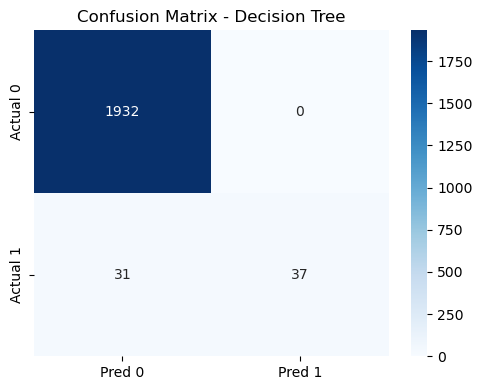

In [53]:
plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Decision Tree")
plt.tight_layout()
plt.show()

In [54]:
print( classification_report(y_test, y_pred) )

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       1.00      0.54      0.70        68

    accuracy                           0.98      2000
   macro avg       0.99      0.77      0.85      2000
weighted avg       0.98      0.98      0.98      2000



In [55]:
imp_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n=== 변수 중요도 상위 10개 ===")
display(imp_df.head(10))


=== 변수 중요도 상위 10개 ===


,feature,importance
6,power_index,0.491
5,temp_diff_k,0.399
2,rotational_speed_rpm,0.079
4,tool_wear_min,0.031
0,air_temp_k,0.000
1,process_temp_k,0.000
3,torque_nm,0.000
7,tool_wear_outlier_flag,0.000
8,type_H,0.000
9,type_L,0.000


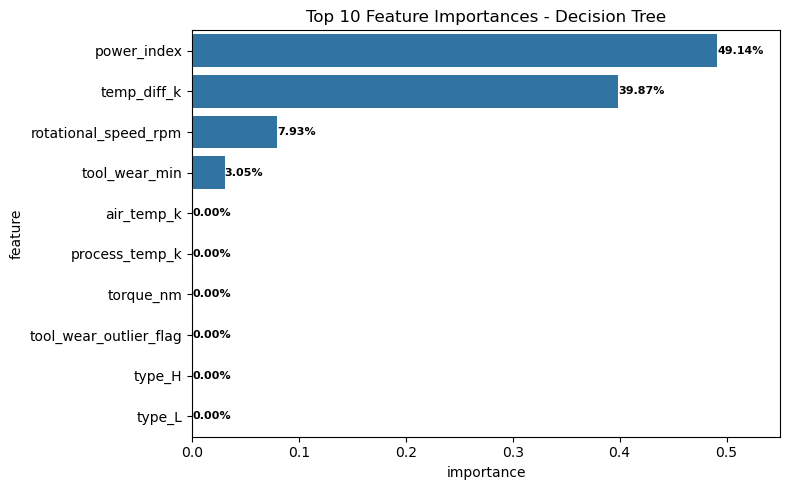

In [56]:
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=imp_df.head(10), x="importance", y="feature")
for i in ax.containers:
    ax.bar_label(i, fmt="{:.2%}", fontsize=8, color="black", fontweight="bold")
plt.xlim(0, 0.55)
plt.title("Top 10 Feature Importances - Decision Tree")
plt.tight_layout()
plt.show()

In [57]:
# end